## Application 2: hyperparameter tuning figures

In [ ]:
from pathlib import Path
import sys

# --- Resolve repo root (works whether you run from repo root or within notebooks/) ---
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    if (REPO_ROOT.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent
    elif (REPO_ROOT.parent.parent / "src").exists():
        REPO_ROOT = REPO_ROOT.parent.parent

sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

from IPython.display import display
from notebooks.set_up import (
    ensure_dirs,
    FIG_DIR,
    CATE_DIR, 
)

ensure_dirs()

# Inputs
output_result = str(CATE_DIR) + "/"

# Outputs
output_figure = FIG_DIR

# For legacy code that uses string concatenation:
output_figure = str(output_figure) + "/"


# Create plots for Application 2

estimator,n_reps,runtime_mean_sec,runtime_sd_sec,ate_rmse,ate_bias_mean,ate_bias_sd,ate_stderr_mean,ate_coverage,cate_rmse_mean,cate_rmse_sd,cate_coverage_mean,min_node,num_trees
CausalForest_min10_trees1000,50,11.751,0.441,0.009,0.0,0.009,0.009,0.92,0.031,0.004,0.852,10.0,1000.0
CausalForest_min10_trees2000,50,22.571,0.801,0.009,0.0,0.009,0.009,0.94,0.031,0.004,0.843,10.0,2000.0
CausalForest_min10_trees4000,50,45.989,1.807,0.009,0.0,0.009,0.009,0.94,0.031,0.004,0.844,10.0,4000.0
CausalForest_min10_trees500,50,7.139,0.86,0.009,-0.0,0.009,0.009,0.94,0.031,0.004,0.869,10.0,500.0
CausalForest_min20_trees1000,50,11.194,0.558,0.009,0.0,0.009,0.009,0.92,0.027,0.004,0.818,20.0,1000.0
CausalForest_min20_trees2000,50,20.823,0.757,0.009,0.0,0.009,0.009,0.94,0.027,0.004,0.817,20.0,2000.0
CausalForest_min20_trees4000,50,42.109,1.966,0.009,0.0,0.009,0.009,0.94,0.027,0.004,0.823,20.0,4000.0
CausalForest_min20_trees500,50,7.002,1.218,0.009,-0.0,0.009,0.009,0.94,0.027,0.004,0.83,20.0,500.0
CausalForest_min40_trees1000,50,10.33,0.65,0.009,0.0,0.009,0.009,0.92,0.025,0.003,0.789,40.0,1000.0
CausalForest_min40_trees2000,50,18.873,0.729,0.009,0.0,0.009,0.009,0.94,0.025,0.003,0.792,40.0,2000.0


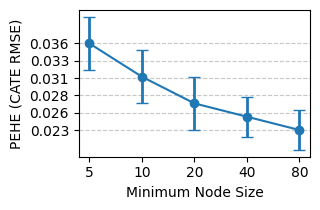

In [0]:
# create the plot of PEHE against minimum leaf(node) size for each estimator
## import the summary data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hp_results = pd.read_csv(output_result + "summary_hp_results.csv")
## extract the min_node size
hp_results["min_node"] = hp_results["estimator"].str.extract(r"min(\d+)_").astype(float)
## extract the number after "trees" as num_trees
hp_results["num_trees"] = hp_results["estimator"].str.extract(r"trees(\d+)").astype(float)
display(hp_results)
## filter for num_trees == 2000
hp_results_2000 = hp_results[hp_results["num_trees"] == 2000]
## sort by min_node to ensure equal spacing on x-axis
hp_results_sorted = hp_results_2000.sort_values("min_node").reset_index(drop=True)
## round y values to three decimals
y_means = hp_results_sorted["cate_rmse_mean"].round(3)
y_errs = hp_results_sorted["cate_rmse_sd"].round(3)
## plot the figure of cate_rmse_mean (with cate_rmse_sd as the error bars) against min_node size and save it to pdf vector figure
#plt.figure(figsize=(4, 3))  # reduce figure size to shrink x-axis spacing
plt.figure(figsize=(3.3, 2.2))
plt.errorbar(
    range(len(hp_results_sorted["min_node"])),
    y_means,
    yerr=y_errs,
    fmt='o-', capsize=4, elinewidth=2, markersize=6
)
plt.xticks(range(len(hp_results_sorted["min_node"])), hp_results_sorted["min_node"].astype(int))
plt.xlabel("Minimum Node Size")
plt.ylabel("PEHE (CATE RMSE)")
# Set evenly spaced y-ticks with 3 decimals
ymin, ymax = y_means.min(), y_means.max()
yticks = np.linspace(ymin, ymax, num=6)
plt.gca().set_yticks(yticks)
plt.gca().set_yticklabels([f"{y:.3f}" for y in yticks])
#plt.title("PEHE vs. Minimum Leaf Size (num_trees=2000)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(output_figure + "pehe_min_node.pdf", format="pdf", bbox_inches="tight")
plt.show()

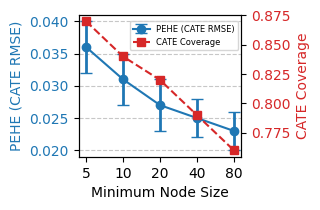

In [0]:
# plot PEHE (CATE RMSE) and CATE Coverage against minimum leaf(node) size for each estimator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

hp_results = pd.read_csv(output_result + "summary_hp_results.csv")
hp_results["min_node"] = hp_results["estimator"].str.extract(r"min(\d+)_").astype(float)
hp_results["num_trees"] = hp_results["estimator"].str.extract(r"trees(\d+)").astype(float)
hp_results_2000 = hp_results[hp_results["num_trees"] == 2000]
hp_results_sorted = hp_results_2000.sort_values("min_node").reset_index(drop=True)

y_means = hp_results_sorted["cate_rmse_mean"].round(3)
y_errs = hp_results_sorted["cate_rmse_sd"].round(3)
cate_coverage = hp_results_sorted["cate_coverage_mean"].round(2)
min_nodes = hp_results_sorted["min_node"].astype(int)

fig, ax1 = plt.subplots(figsize=(3.3, 2.2))
color1 = "#1f77b4"
color2 = "#d62728"

ax1.errorbar(
    range(len(min_nodes)),
    y_means,
    yerr=y_errs,
    fmt='o-', capsize=4, elinewidth=2, markersize=6, color=color1, label="PEHE (CATE RMSE)"
)
ax1.set_xlabel("Minimum Node Size")
ax1.set_ylabel("PEHE (CATE RMSE)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(range(len(min_nodes)))
ax1.set_xticklabels(min_nodes)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(range(len(min_nodes)), cate_coverage, 's--', color=color2, label="CATE Coverage")
ax2.set_ylabel("CATE Coverage", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2, loc="upper right", bbox_to_anchor=(0.75, 0.90), fontsize=6)

plt.tight_layout()
plt.savefig(output_figure + "pehe_coverage_min_node.pdf", format="pdf", bbox_inches="tight")
plt.show()

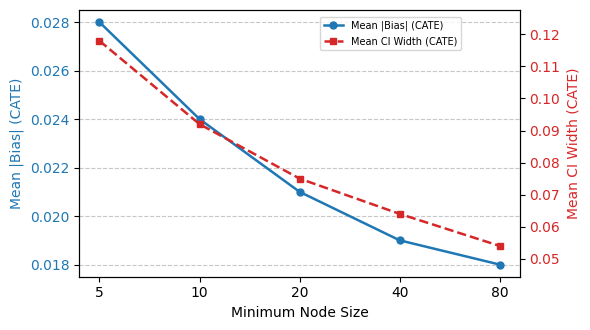

In [0]:
# added 2/23/2026
# Bias–CI width plot (Causal Forest, 2000 trees)
# Two curves: mean absolute CATE bias and mean CATE CI width

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


# Load summary results
hp = pd.read_csv(output_result + "summary_hp_results.csv")

# Extract hyperparameters
hp["min_node"] = hp["estimator"].str.extract(r"min(\d+)_").astype(int)
hp["num_trees"] = hp["estimator"].str.extract(r"trees(\d+)").astype(int)

# Filter to 2000 trees and sort
hp = hp[hp["num_trees"] == 2000].sort_values("min_node")

min_nodes = hp["min_node"].to_numpy()
x = np.arange(len(min_nodes))

bias_mae = hp["cate_bias_abs_mean_mean"].to_numpy()
ci_width = hp["cate_ci_width_mean_mean"].to_numpy()

fig, ax1 = plt.subplots(figsize=(6, 3.4))
color1 = "#1f77b4"
color2 = "#d62728"

# ---- Left axis: Mean absolute bias ----
ax1.plot(x, bias_mae, 'o-', linewidth=1.8, markersize=5,
         color=color1, label="Mean |Bias| (CATE)")
ax1.set_xlabel("Minimum Node Size")
ax1.set_ylabel("Mean |Bias| (CATE)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # round to 3 decimals
ax1.set_xticks(x)
ax1.set_xticklabels(min_nodes)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# ---- Right axis: Mean CI width ----
ax2 = ax1.twinx()
ax2.plot(x, ci_width, 's--', linewidth=1.8, markersize=5,
         color=color2, label="Mean CI Width (CATE)")
ax2.set_ylabel("Mean CI Width (CATE)", color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Rescale CI-width axis to avoid visual overlap
ci_min, ci_max = ci_width.min(), ci_width.max()
margin = 0.15 * (ci_max - ci_min if ci_max > ci_min else ci_max)
ax2.set_ylim(ci_min - margin, ci_max + margin)

# ---- Legend ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2,
           loc="upper right", bbox_to_anchor=(0.785, 0.95), fontsize=7)

plt.tight_layout()
plt.savefig(output_figure + "bias_ciw_trees2000.pdf",
            format="pdf", bbox_inches="tight")
plt.show()

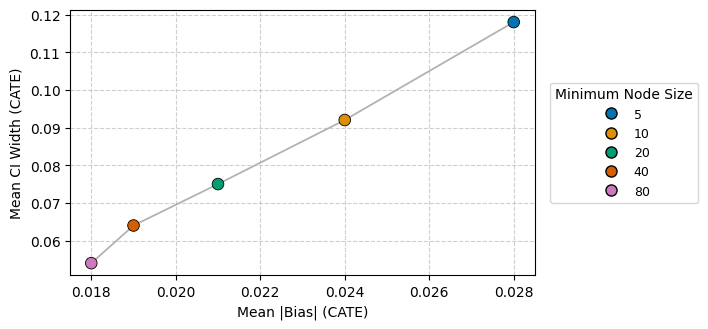

In [0]:
# added 2/23/2026
# Bias vs. CI width(Causal Forest, 2000 trees)
# Colorblind-safe palette (no red–green conflict)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D
import seaborn as sns


# ---- Load + filter ----
hp = pd.read_csv(output_result + "summary_hp_results.csv")
hp["min_node"] = hp["estimator"].str.extract(r"min(\d+)_").astype(int)
hp["num_trees"] = hp["estimator"].str.extract(r"trees(\d+)").astype(int)

hp = hp[hp["num_trees"] == 2000].sort_values("min_node")

leaf = hp["min_node"].to_numpy()
x = hp["cate_bias_abs_mean_mean"].to_numpy(dtype=float)
y = hp["cate_ci_width_mean_mean"].to_numpy(dtype=float)

# ---- Colorblind-safe discrete palette ----
colors = sns.color_palette("colorblind", n_colors=len(leaf))

# ---- Two-column sized figure ----
fig, ax = plt.subplots(figsize=(7.2, 3.4))

# Neutral trajectory line
ax.plot(x, y, linewidth=1.3, color="gray", alpha=0.6, zorder=1)

# Scatter points
ax.scatter(
    x, y,
    s=70,
    c=colors,
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

ax.set_xlabel("Mean |Bias| (CATE)")
ax.set_ylabel("Mean CI Width (CATE)")
ax.xaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax.grid(True, linestyle="--", alpha=0.6)

# ---- Legend outside ----
legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        label=str(mn),
        markerfacecolor=col,
        markeredgecolor="black",
        markersize=8
    )
    for mn, col in zip(leaf, colors)
]

ax.legend(
    handles=legend_elements,
    title="Minimum Node Size",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

plt.tight_layout()
plt.savefig(output_figure + "bias_vs_ciw_trees2000.pdf",
            format="pdf", bbox_inches="tight")
plt.show()